# Multi-Op Paper Analysis

This notebook is a minimal analysis workflow for the multi-operation transformer experiments used in the paper.

What this notebook covers:
- Load one experiment folder from `paper_rerun_models/`
- Evaluate overall and per-operation accuracy from checkpoint
- Run Fourier/SVD/ablation analyses used for the paper figures
- Provide templates for pairwise accuracy summary and add/mult split ablation

Expected run folders:
- `paper_rerun_models/add_sub`
- `paper_rerun_models/add_mult`
- `paper_rerun_models/add_div`
- `paper_rerun_models/div_sub`
- `paper_rerun_models/div_mult`
- `paper_rerun_models/mult_sub`
- `paper_rerun_models/add_mult_split`


In [9]:
# Notebook bootstrap: make project imports work from any launch directory.
from pathlib import Path
import os
import sys

try:
    ip = get_ipython()  # type: ignore[name-defined]
    if ip is not None:
        ip.run_line_magic('load_ext', 'autoreload')
        ip.run_line_magic('autoreload', '2')
except Exception:
    pass

cwd = Path.cwd().resolve()
REPO_ROOT = None
for candidate in [cwd, *cwd.parents]:
    if (candidate / 'main.py').exists() and (candidate / 'config').is_dir():
        REPO_ROOT = candidate
        break
if REPO_ROOT is None:
    raise RuntimeError('Could not locate repository root (expected main.py and config/).')

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)
print(f'Using repo root: {REPO_ROOT}')

import torch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import copy
import traceback

from training import *
from utils import *
from analysis.common_fourier import *
from analysis.common_trig import *
from config import Config
from analysis.analysis_utils import *
from utils import (
    get_device,
    create_dataset,
    create_model,
    print_dataset_info,
    evaluate_model,
    filter_data_by_operation,
    load_model,
    plot_training_curves,
    resolve_checkpoint,
    extract_checkpoint_accuracies,
)
from analysis.rnn import ablation as rnn_ablation
from analysis.rnn import combined_ablation as rnn_combined_ablation
from analysis.rnn import fourier as rnn_fourier
from analysis.rnn import svd as rnn_svd
from analysis.rnn import trig as rnn_trig
from analysis.transformer import ablation as transformer_ablation
from analysis.transformer import combined_ablation as transformer_combined_ablation
from analysis.transformer import fourier as transformer_fourier
from analysis.transformer import svd as transformer_svd
from analysis.transformer import trig as transformer_trig

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Using repo root: /Users/adirathodd/Desktop/NJIT/rnn-research/icml_submissions/fourier_regularization


In [10]:
import torch

# Select one experiment directory to analyze.
# Set EXPERIMENT_KEY to one of the keys below.
RUN_OPTIONS = {
    'add_sub': 'paper_rerun_models/add_sub',
    'add_mult': 'paper_rerun_models/add_mult',
    'add_div': 'paper_rerun_models/add_div',
    'div_sub': 'paper_rerun_models/div_sub',
    'div_mult': 'paper_rerun_models/div_mult',
    'mult_sub': 'paper_rerun_models/mult_sub',
    'add_mult_split': 'paper_rerun_models/add_mult_split',
}

EXPERIMENT_KEY = 'add_mult_split'
EXPERIMENT_PATH = str(REPO_ROOT / RUN_OPTIONS[EXPERIMENT_KEY])

print(f'Analyzing experiment at: {EXPERIMENT_PATH}')

config_path = f'{EXPERIMENT_PATH}/config.yaml'
ckpt_path = f'{EXPERIMENT_PATH}/checkpoints/best.pt'
if not os.path.exists(ckpt_path):
    ckpt_path = f'{EXPERIMENT_PATH}/checkpoints/final.pt'
print(f'Using checkpoint: {ckpt_path}')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


Analyzing experiment at: /Users/adirathodd/Desktop/NJIT/rnn-research/icml_submissions/fourier_regularization/paper_rerun_models/add_mult_split
Using checkpoint: /Users/adirathodd/Desktop/NJIT/rnn-research/icml_submissions/fourier_regularization/paper_rerun_models/add_mult_split/checkpoints/best.pt


In [11]:
# Load Configuration
if os.path.exists(config_path):
    print(f"Loading configuration from {config_path}")
    config = Config.load(config_path)
    # Ensure config knows where to save outputs (figures)
    config.training.save_dir = EXPERIMENT_PATH 
else:
    raise FileNotFoundError(f"No config file found at {config_path}")

device = get_device(None)
print(f"Using device: {device}")

if config.model_type == 'transformer':
    print("Model Type: Transformer")
else:
    print("Model Type: RNN")

print("Operations:", config.operations)

# Show configured training epoch count
epoch_count = getattr(getattr(config, "training", None), "epochs", None)
if epoch_count is not None:
    print(f"Epochs: {epoch_count}")
else:
    print("Epochs: not set in config.training")

# Create Dataset
dataset = create_dataset(config.operations, config.data.to_dict(), device)
print(f"Dataset created with size: {len(dataset)}")
print(f"Operations: {config.operations}")


Loading configuration from /Users/adirathodd/Desktop/NJIT/rnn-research/icml_submissions/fourier_regularization/paper_rerun_models/add_mult_split/config.yaml
Using device: mps
Model Type: Transformer
Operations: ['addition', 'multiplication']
Epochs: 10000
Dataset created with size: 25313
Operations: ['addition', 'multiplication']


In [12]:
print('\n=== Fourier Spectrum Analysis Report ===\n')

# Notebook mode: view plots inline only (disable file writes)
SAVE_FIGURES = False
if not SAVE_FIGURES:
    try:
        ip = get_ipython()  # type: ignore[name-defined]
        if ip is not None:
            ip.run_line_magic('matplotlib', 'inline')
    except Exception:
        pass

    from IPython.display import display

    def _display_instead_of_savefig(*args, **kwargs):
        # analysis helpers call savefig() then close(); display before close.
        display(plt.gcf())

    plt.savefig = _display_instead_of_savefig
    print('Figure saving disabled; figures will display inline.')

analysis_path = EXPERIMENT_PATH
ckpt_path = ckpt_path if os.path.exists(ckpt_path) else resolve_checkpoint(analysis_path)
model, checkpoint = load_model(ckpt_path, config.model.to_dict(), device=str(device))
dataset = dataset.to_device(str(device))
analysis_cache = {}

if config.model_type == 'transformer':
    fourier_analysis = transformer_fourier
    svd_analysis = transformer_svd
    ablation_analysis = transformer_ablation
    combined_ablation_analysis = transformer_combined_ablation
    trig_analysis = transformer_trig
else:
    fourier_analysis = rnn_fourier
    svd_analysis = rnn_svd
    ablation_analysis = rnn_ablation
    combined_ablation_analysis = rnn_combined_ablation
    trig_analysis = rnn_trig

train_acc, test_acc, epoch = extract_checkpoint_accuracies(checkpoint)

print(f"Epoch: {epoch if epoch is not None else 'N/A'}")
print('1. Model performance:')
train_acc_str = f'{train_acc}%' if train_acc is not None else 'N/A'
test_acc_str  = f'{test_acc}%'  if test_acc  is not None else 'N/A'
print(
    f'Accuracy on entire dataset: {evaluate_model(model, dataset.dataset, dataset.labels)}%'
    f' \n\t Train set accuracy: {train_acc_str}'
    f' \n\t Test set accuracy: {test_acc_str}'
)
print('Per-operation accuracy:')
for op in config.operations:
    op_all_data, op_all_labels = filter_data_by_operation(dataset, op, split='all', target='final')
    op_train_data, op_train_labels = filter_data_by_operation(dataset, op, split='train', target='final')
    op_test_data, op_test_labels = filter_data_by_operation(dataset, op, split='test', target='final')

    op_all_acc = evaluate_model(model, op_all_data, op_all_labels)
    op_train_acc = evaluate_model(model, op_train_data, op_train_labels)
    op_test_acc = evaluate_model(model, op_test_data, op_test_labels)

    print(
        f' \n\t {op.capitalize()} - total: {op_all_acc}%'
        f' \n\t {op.capitalize()} - train: {op_train_acc}%'
        f' \n\t {op.capitalize()} - test: {op_test_acc}%'
    )



=== Fourier Spectrum Analysis Report ===

Figure saving disabled; figures will display inline.
Epoch: 9146
1. Model performance:
Accuracy on entire dataset: 99.99209892150279% 
	 Train set accuracy: 100.0% 
	 Test set accuracy: 99.98784490093594%
Per-operation accuracy:
 
	 Addition - total: 100.0% 
	 Addition - train: 100.0% 
	 Addition - test: 100.0%
 
	 Multiplication - total: 99.98405612244898% 
	 Multiplication - train: 100.0% 
	 Multiplication - test: 99.97547216090263%



=== ADDITION ===
2. Generating fourier coefficient analysis plots


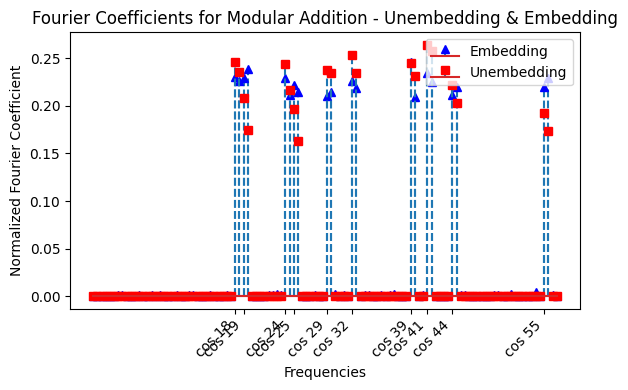

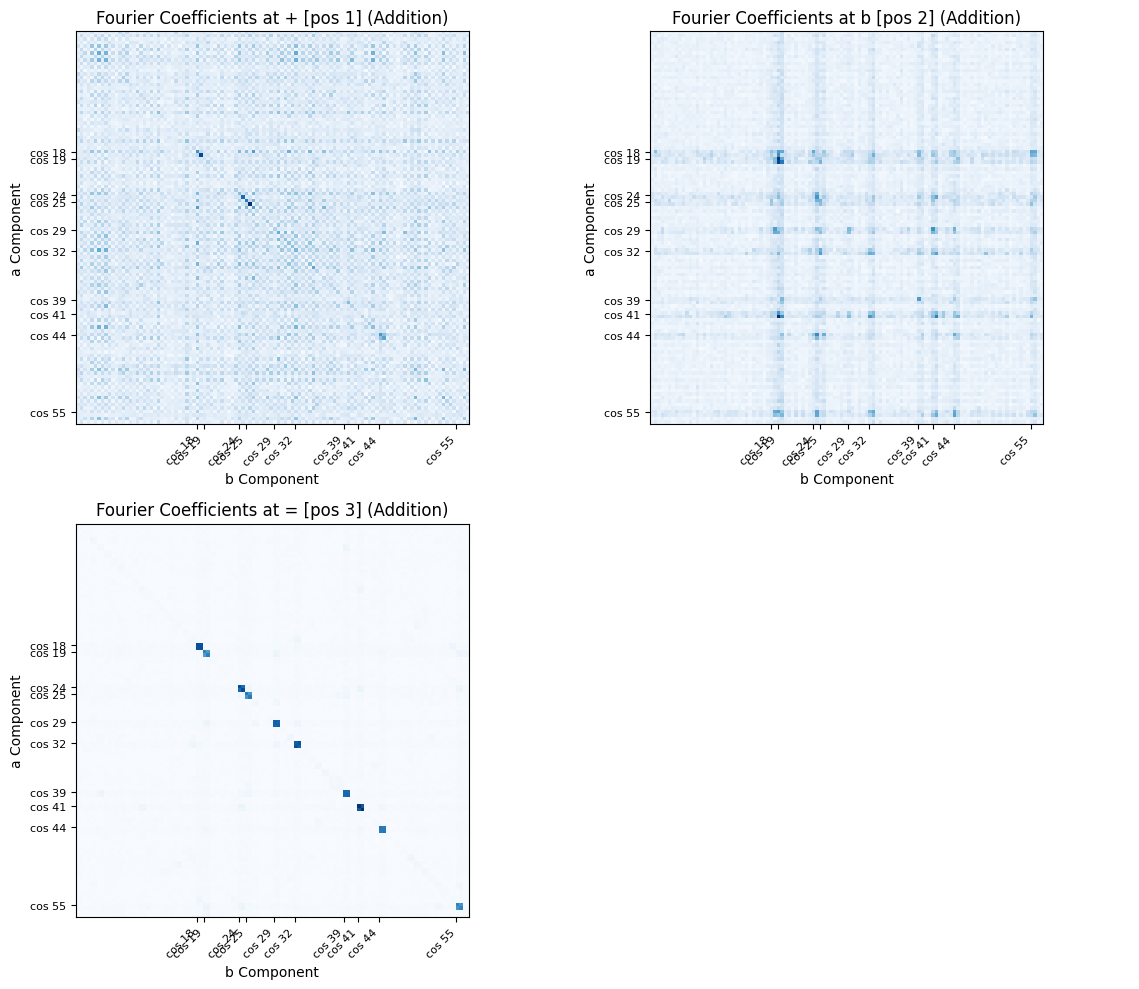

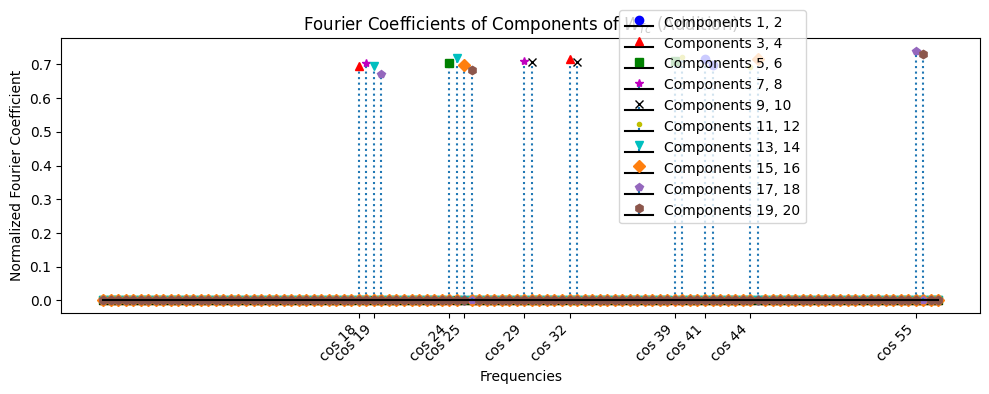


3. Performing SVD ablation analysis
Accuracy after ablating insignificant components (Addition): 15.77%
  -> Accuracy on multiplication: 0.97%
Accuracy after ablating all significant components (Addition): 2.65%
  -> Accuracy on multiplication: 0.69%

4. Performing fourier component ablation analysis
Fourier ablation analysis for Addition:
  Accuracy after ablating:
    Only Freq 1: 14.27%
    Until Freq 1: 14.27%
  Accuracy after ablating:
    Only Freq 2: 12.92%
    Until Freq 2: 11.28%
  Accuracy after ablating:
    Only Freq 3: 14.07%
    Until Freq 3: 10.33%
  Accuracy after ablating:
    Only Freq 4: 13.48%
    Until Freq 4: 7.83%
  Accuracy after ablating:
    Only Freq 5: 13.24%
    Until Freq 5: 6.20%
  Accuracy after ablating:
    Only Freq 6: 13.81%
    Until Freq 6: 4.60%
  Accuracy after ablating:
    Only Freq 7: 14.33%
    Until Freq 7: 4.08%
  Accuracy after ablating:
    Only Freq 8: 14.55%
    Until Freq 8: 3.28%
  Accuracy after ablating:
    Only Freq 9: 14.42%
   

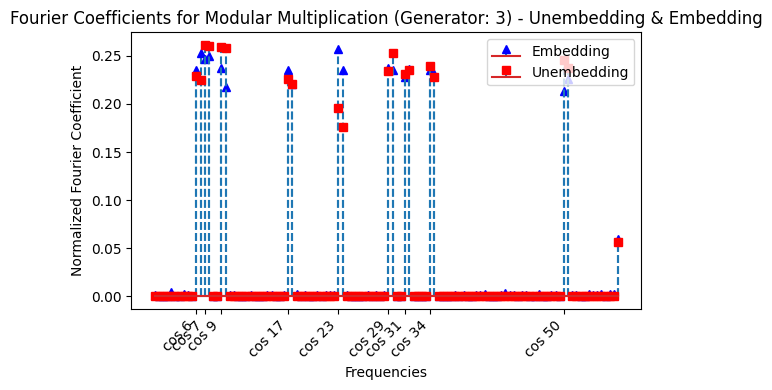

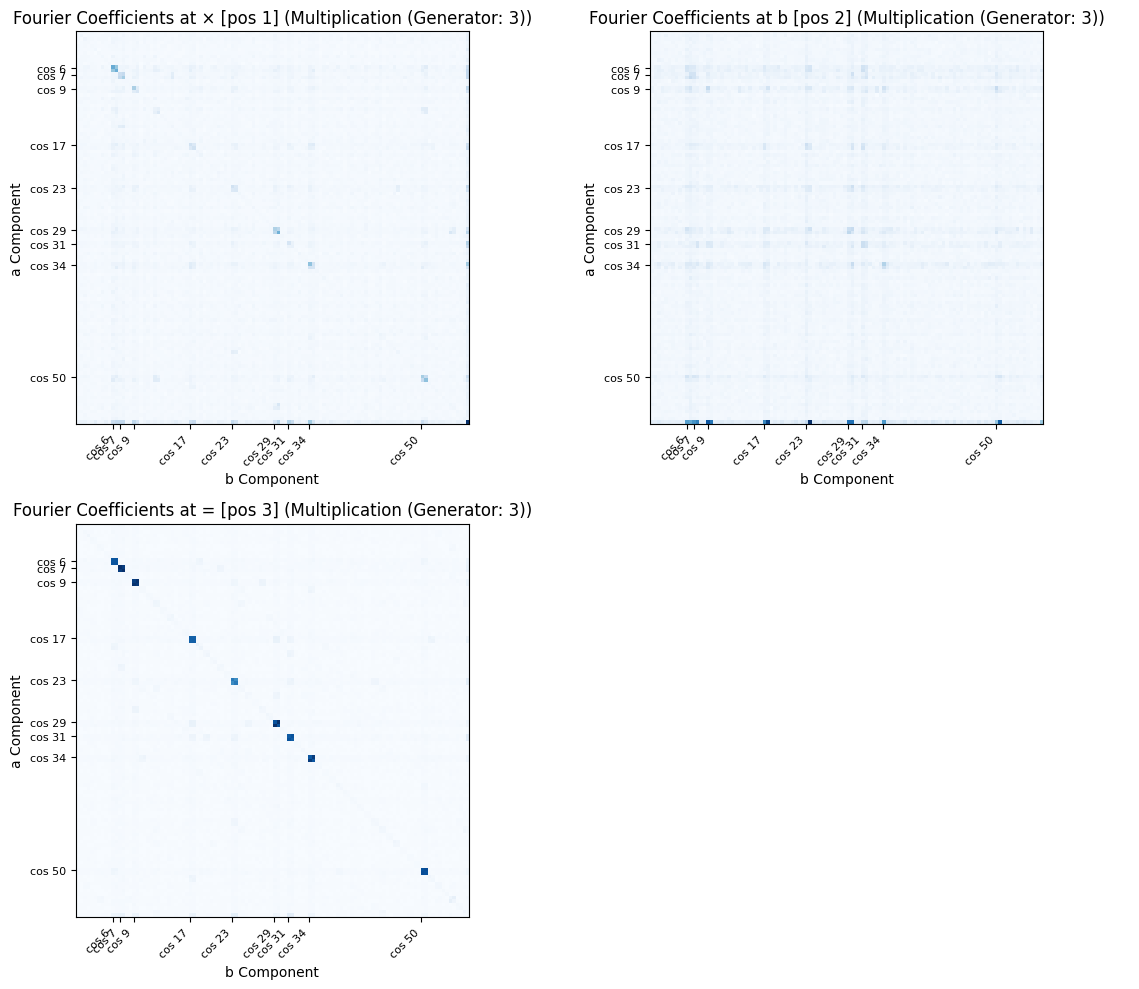

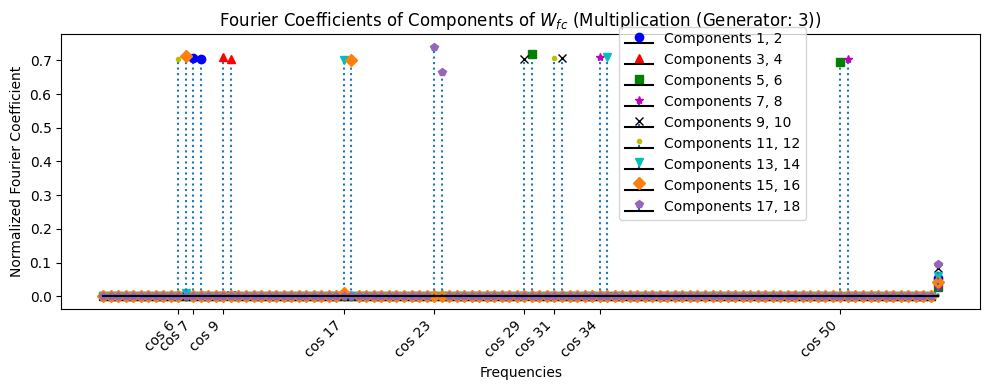


3. Performing SVD ablation analysis
Accuracy after ablating insignificant components (Multiplication): 21.09%
  -> Accuracy on addition: 0.81%
Accuracy after ablating all significant components (Multiplication): 1.84%
  -> Accuracy on addition: 0.88%

4. Performing fourier component ablation analysis
Fourier ablation analysis for Multiplication:
  Accuracy after ablating:
    Only Freq 1: 18.75%
    Until Freq 1: 18.75%
  Accuracy after ablating:
    Only Freq 2: 17.40%
    Until Freq 2: 15.33%
  Accuracy after ablating:
    Only Freq 3: 17.44%
    Until Freq 3: 12.63%
  Accuracy after ablating:
    Only Freq 4: 18.04%
    Until Freq 4: 9.98%
  Accuracy after ablating:
    Only Freq 5: 17.79%
    Until Freq 5: 7.60%
  Accuracy after ablating:
    Only Freq 6: 18.11%
    Until Freq 6: 5.81%
  Accuracy after ablating:
    Only Freq 7: 17.68%
    Until Freq 7: 3.85%
  Accuracy after ablating:
    Only Freq 8: 17.82%
    Until Freq 8: 2.12%
  Accuracy after ablating:
    Only Freq 9: 19.6

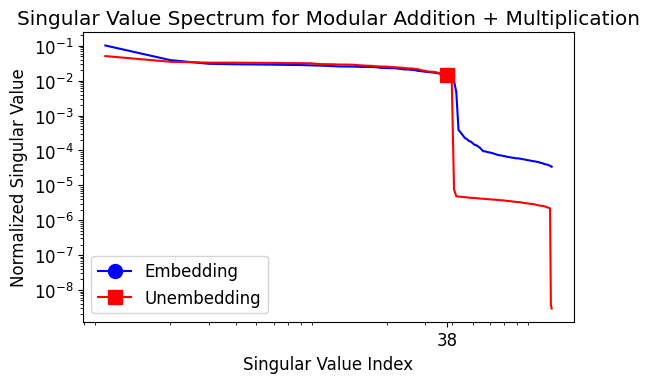


7. Performing combined-ip-elbow embedding/unembedding ablation analysis
Combined-ip-elbow ablation (Transformer): keeping top 38 components in embedding/unembedding
  -> Accuracy on addition: 96.84%
  -> Accuracy on multiplication: 92.70%

8. Plotting per-operation accuracy vs kept top-k singular components
Combined-ip-elbow accuracy sweep (transformer): evaluating k=0..43 (embedding/unembedding top-k components kept)


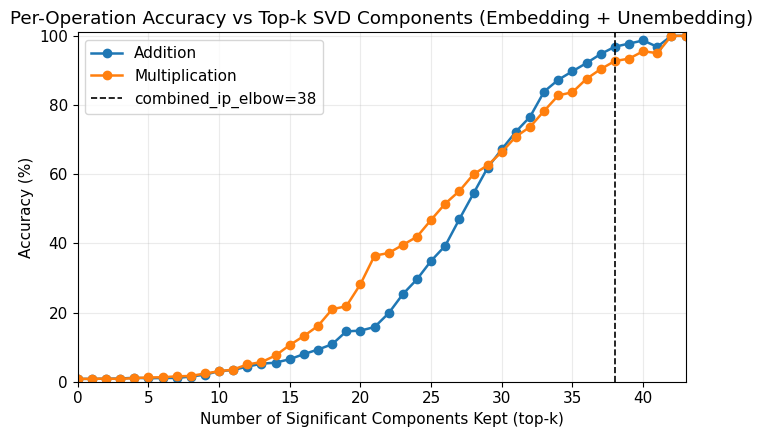

Saved combined-ip accuracy curve: /Users/adirathodd/Desktop/NJIT/rnn-research/icml_submissions/fourier_regularization/paper_rerun_models/add_mult_split/figures/combined_ip_svd_accuracy_curve.png

=== Analysis Complete ===


In [13]:

op_elbows = {}
for op in config.operations:
    op_elbows[op] = fourier_analysis.compute_ip_elbow(
        checkpoint, dataset, op,
        norm_threshold=config.analysis.fourier_norm_threshold,
        fourier_reg_mode=config.training.fourier_reg_mode,
        analysis_cache=analysis_cache,
    )

for op in config.operations:
    ip_elbow = op_elbows[op]
    print(f'\n=== {op.upper()} ===')

    print('2. Generating fourier coefficient analysis plots')
    fourier_analysis.fourier_spectrum_analysis_plotting(
        model, checkpoint, dataset, analysis_path, op,
        fourier_reg_mode=config.training.fourier_reg_mode,
        norm_threshold=config.analysis.fourier_norm_threshold,
        freq_threshold_top_fraction=config.analysis.freq_threshold_top_fraction,
        freq_threshold_min_components=config.analysis.freq_threshold_min_components,
        freq_threshold_fixed=config.analysis.freq_threshold_fixed,
        analysis_cache=analysis_cache,
    )
    print()

    print('3. Performing SVD ablation analysis')
    try:
        ablation_analysis.svd_ablation_analysis(
            config.model.to_dict(), checkpoint, dataset, op, ip_elbow,
            fourier_reg_mode=config.training.fourier_reg_mode,
            analysis_cache=analysis_cache,
        )
    except Exception as e:
        print(f'Exception: {e}')
    print()

    print('4. Performing fourier component ablation analysis')
    try:
        ablation_analysis.fourier_ablation_analysis(
            config.model.to_dict(), checkpoint, dataset, op, ip_elbow,
            fourier_reg_mode=config.training.fourier_reg_mode,
            analysis_cache=analysis_cache,
        )
    except Exception as e:
        print(f'Exception: {e}')
    print()

    if op in ('addition', 'subtraction'):
        print('5. Trigonometric Identity Verification:')
        try:
            if op == 'addition':
                trig_analysis.verify_trigonometric_identity(
                    model,
                    checkpoint,
                    dataset,
                    freq_threshold_top_fraction=config.analysis.freq_threshold_top_fraction,
                    freq_threshold_min_components=config.analysis.freq_threshold_min_components,
                    freq_threshold_fixed=config.analysis.freq_threshold_fixed,
                    analysis_cache=analysis_cache,
                )
            else:
                trig_analysis.verify_trigonometric_identity_subtraction(
                    model,
                    checkpoint,
                    dataset,
                    freq_threshold_top_fraction=config.analysis.freq_threshold_top_fraction,
                    freq_threshold_min_components=config.analysis.freq_threshold_min_components,
                    freq_threshold_fixed=config.analysis.freq_threshold_fixed,
                    analysis_cache=analysis_cache,
                )
        except Exception as e:
            print(f'Exception: {e}')
        print()

print('\n6. Generating Weight SVD spectrum plots (whole model)')
try:
    svd_analysis.svd_spectrum_analysis_plotting_model(
        model,
        checkpoint,
        dataset,
        analysis_path,
        op_elbows,
        config.operations,
        analysis_cache=analysis_cache,
    )
except Exception as e:
    print(f'Exception: {e}')
print()

print('7. Performing combined-ip-elbow embedding/unembedding ablation analysis')
try:
    combined_ablation_analysis.combined_ip_svd_ablation_analysis(
        config.model.to_dict(),
        checkpoint,
        dataset,
        op_elbows,
        config.operations,
        analysis_cache=analysis_cache,
    )
except Exception as e:
    print(f'Exception: {e}')
print()

print('8. Plotting per-operation accuracy vs kept top-k singular components')
try:
    combined_ablation_analysis.combined_ip_svd_ablation_accuracy_curve(
        config.model.to_dict(),
        checkpoint,
        dataset,
        analysis_path,
        op_elbows,
        config.operations,
        analysis_cache=analysis_cache,
    )
except Exception as e:
    print(f'Exception: {e}')
print()

print('=== Analysis Complete ===')

In [14]:
# Table 3 metrics: split-embedding half-mask ablation
import copy
from pathlib import Path

run_dir = Path(EXPERIMENT_PATH)
cfg = Config.load(str(run_dir / 'config.yaml'), skip_validation=True)
mode = getattr(cfg.training, 'fourier_reg_mode', None)

if mode != 1:
    print(f'Skipping Table 3 ablation: selected run has fourier_reg_mode={mode}, not split embedding.')
else:
    # Reuse notebook objects when available; otherwise load from selected run.
    local_dataset = globals().get('dataset', None)
    local_model = globals().get('model', None)

    if local_dataset is None or local_model is None:
        local_dataset = create_dataset(cfg.operations, cfg.data.to_dict(), device=str(device))
        ckpt_path = run_dir / 'checkpoints' / 'best.pt'
        if not ckpt_path.exists():
            ckpt_path = run_dir / 'checkpoints' / 'final.pt'
        local_model, _ = load_model(str(ckpt_path), cfg.model.to_dict(), device=str(device))

    def op_acc(m):
        out = {}
        for op in cfg.operations:
            d, l = filter_data_by_operation(local_dataset, op, split='all', target='final')
            out[op] = evaluate_model(m, d, l)
        return out

    baseline = op_acc(local_model)

    # Copy model state so each ablation is isolated and non-destructive.
    state = copy.deepcopy(local_model.state_dict())
    d_model = state['embedding.weight'].shape[1]
    half = d_model // 2

    m_first = copy.deepcopy(local_model)
    st_first = copy.deepcopy(state)
    st_first['embedding.weight'][:, :half] = 0
    st_first['fc.weight'][:, :half] = 0
    m_first.load_state_dict(st_first)
    mask_first = op_acc(m_first)

    m_second = copy.deepcopy(local_model)
    st_second = copy.deepcopy(state)
    st_second['embedding.weight'][:, half:] = 0
    st_second['fc.weight'][:, half:] = 0
    m_second.load_state_dict(st_second)
    mask_second = op_acc(m_second)

    print('Table 3-style ablation metrics (%)')
    print('Operation\tBaseline\tMask first half\tMask second half')
    for op in cfg.operations:
        print(f'{op}\t{baseline[op]:.2f}\t{mask_first[op]:.2f}\t{mask_second[op]:.2f}')


Table 3-style ablation metrics (%)
Operation	Baseline	Mask first half	Mask second half
addition	100.00	1.25	96.78
multiplication	99.98	95.48	0.71
